In [1]:
%load_ext autoreload
%autoreload 2

# Compare the distribution of flux ranges from FVA for each model

In [3]:
import cobra
import pandas
import numpy as np
import matplotlib.pyplot as plt

from cobra.flux_analysis import flux_variability_analysis

from utilities.helper_create_model import get_irreversible_model
from utilities.utils import ec_to_og_fva_mapping, cumulative_flux_variability_graph


In [11]:
models_dict = {
    'MitoCore_Original_plt': './../parameterized_plt_models/MitoCore_Original_plt.xml',
    'Mitocore_Preliminary': './../autopacmen_output/Mitocore_Preliminary/Mitocore_Preliminary_calibrated.xml',
    'Mitocore_MitoMammal': './../autopacmen_output/Mitocore_MitoMammal/Mitocore_MitoMammal_calibrated.xml',
    'Mitocore_aligned_to_Human1': './../autopacmen_output/Mitocore_aligned_to_Human1/Mitocore_aligned_to_Human1_calibrated.xml',
}

# 1) Perform "normal" FVA for every model

- reversible reactions should be split into forward and reverse reactions
- parallel reactions should be mapped to original reactions

In [12]:
# get original reactions
og_model = cobra.io.read_sbml_model(models_dict["MitoCore_Original_plt"])
irreversible_og_model = get_irreversible_model(og_model, "_TG_")
original_model_reactions = [reaction.id for reaction in irreversible_og_model.reactions]

fva_normal_results_dict = {}
fva_normal_results_mapped_dict = {}

# perform fva and store results
for key, value in models_dict.items():
    df_mapped = pandas.DataFrame(index=original_model_reactions, columns=["minimum", "maximum"])

    # load model
    model = cobra.io.read_sbml_model(value)
    model = get_irreversible_model(model, "_TG_", no_gpr_split=True)
    
    # for reaction in model.reactions:
    #     if reaction.upper_bound == 1000:
    #         reaction.upper_bound = 100
        
    df_fva = flux_variability_analysis(model, fraction_of_optimum = 0.95, processes = 4)
    
    fva_normal_results_dict[key] = df_fva
    mapped_results_df = ec_to_og_fva_mapping(df_fva, original_model_reactions, model)
            
    fva_normal_results_mapped_dict[key] = mapped_results_df

Set parameter Username
Academic license - for non-commercial use only - expires 2026-09-26


c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")


MitoCore_Original_plt
Mitocore_Preliminary
Mitocore_MitoMammal
Mitocore_aligned_to_Human1


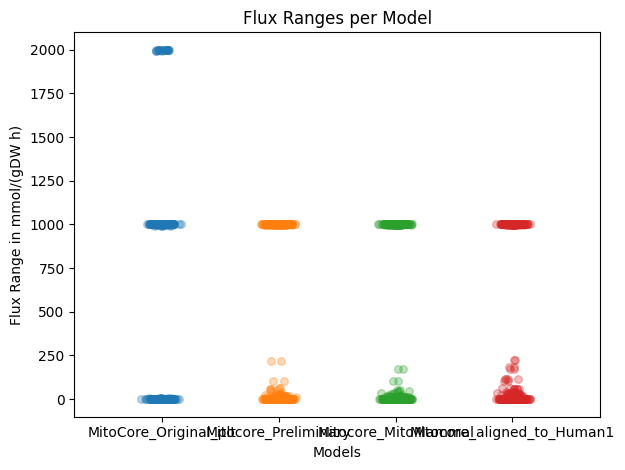

In [14]:
from utilities.utils import fva_scatter_plot

fva_scatter_plot(fva_normal_results_mapped_dict)

Cumulated variabilities:
{'MitoCore_Original_plt': 298039.3257379804, 'Mitocore_Preliminary': 317701.1620465305, 'Mitocore_MitoMammal': 319462.8801468323, 'Mitocore_aligned_to_Human1': 309347.66693520866}
Mean variabilities:
{'MitoCore_Original_plt': 418.594558620759, 'Mitocore_Preliminary': 361.4347691086809, 'Mitocore_MitoMammal': 360.56758481583785, 'Mitocore_aligned_to_Human1': 349.15086561535963}


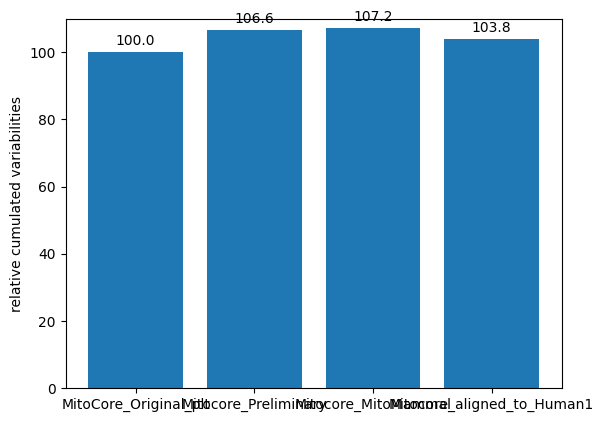

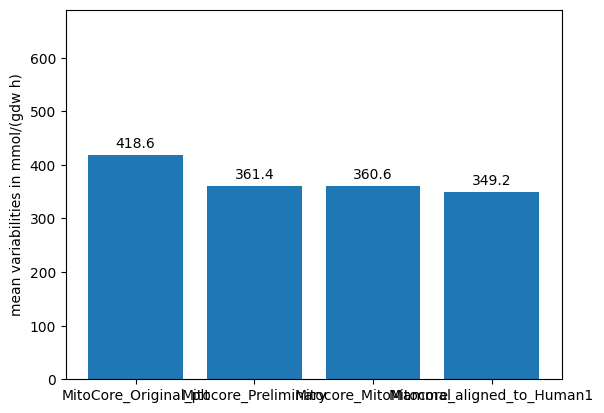

In [15]:
from utilities.utils import statistics_and_barplots

statistics_and_barplots(fva_normal_results_mapped_dict)

------------------MitoCore_Original_plt-----------------
# vars above 500: 277
# vars above 1000: 237
------------------Mitocore_Preliminary-----------------
# vars above 500: 316
# vars above 1000: 289
------------------Mitocore_MitoMammal-----------------
# vars above 500: 318
# vars above 1000: 292
------------------Mitocore_aligned_to_Human1-----------------
# vars above 500: 306
# vars above 1000: 282


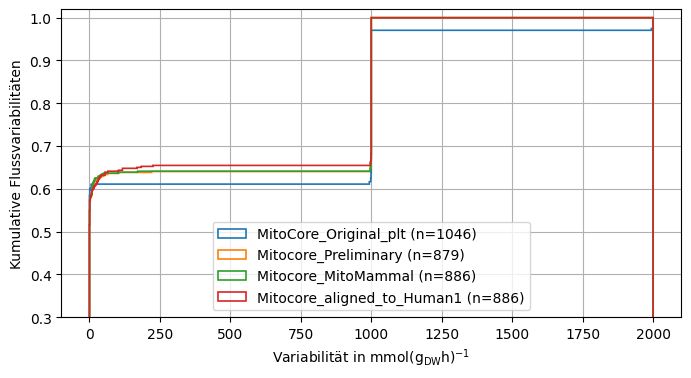

In [16]:
cumulative_flux_variability_graph(fva_normal_results_mapped_dict, '')

In [ ]:
# check which reactions are still fuled by loops
fva_normal_results_mapped_dict['curated'].loc[fva_normal_results_mapped_dict['curated']['range'] > 100]

,range
TPI_TG_forward,278.735422
TPI_TG_reverse,278.709915
GAPD_TG_forward,132.075531
GAPD_TG_reverse,131.981259
RPE_TG_forward,1000.0
...,...
PSt3_TG_reverse,1000.0
PEt_TG_forward,1000.0
PEt_TG_reverse,1000.0
Glycogen_t_TG_forward,1000.0


# 2) Perform FVA while blocking reverse reactions
- this is analogously to the original Paper by Bekiaris, where reverse reactions where blocked
- problem: loops ar blocked selectively, and there will still be loops included in the FVA predictions

In [27]:
from utilities.utils import get_fva_statistics

In [22]:
fva_ec_results_dict = {}
fva_ec_results_mapped_dict = {}

# perform fva and store results
for key, value in models_dict.items():
    df_mapped = pandas.DataFrame(index=original_model_reactions, columns=["minimum", "maximum"])

    # load model
    model = cobra.io.read_sbml_model(value)
    model = get_irreversible_model(model, "_TG_", no_gpr_split=False)

    fva_df = pandas.DataFrame.from_dict(get_fva_statistics(model, 0.95), orient='index')

    fva_ec_results_dict[key] = fva_df

    mapped_ec_results_df = ec_to_og_fva_mapping(fva_df, original_model_reactions, model)
            
    fva_ec_results_mapped_dict[key] = mapped_ec_results_df

c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\neutrophil_modeling_smoment_310\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")


MitoCore_Original_plt
Mitocore_Preliminary
Mitocore_MitoMammal
Mitocore_aligned_to_Human1


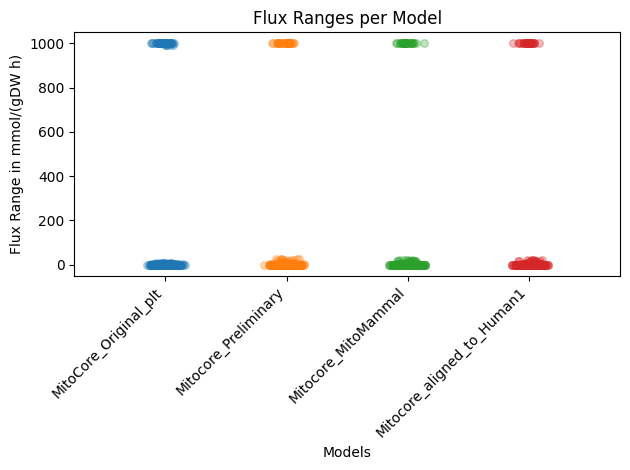

In [31]:
fva_scatter_plot(fva_ec_results_mapped_dict)

Cumulated variabilities:
{'MitoCore_Original_plt': 46083.82667410445, 'Mitocore_Preliminary': 30371.03935947281, 'Mitocore_MitoMammal': 30322.223884534502, 'Mitocore_aligned_to_Human1': 30328.55849199556}
Mean variabilities:
{'MitoCore_Original_plt': 53.89921248433269, 'Mitocore_Preliminary': 35.646759811587806, 'Mitocore_MitoMammal': 35.29944573286904, 'Mitocore_aligned_to_Human1': 35.306820130379}


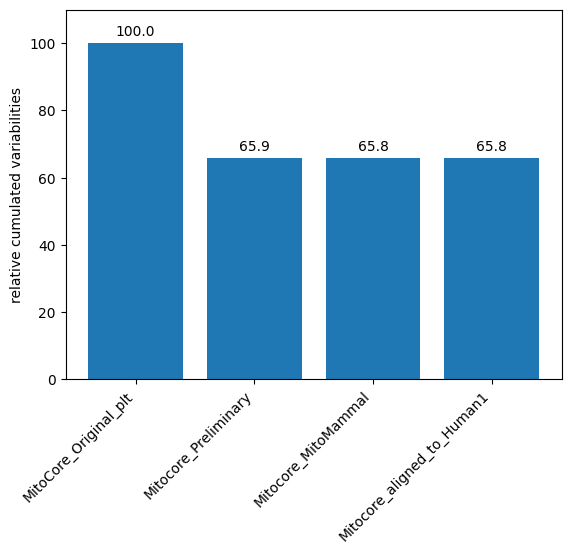

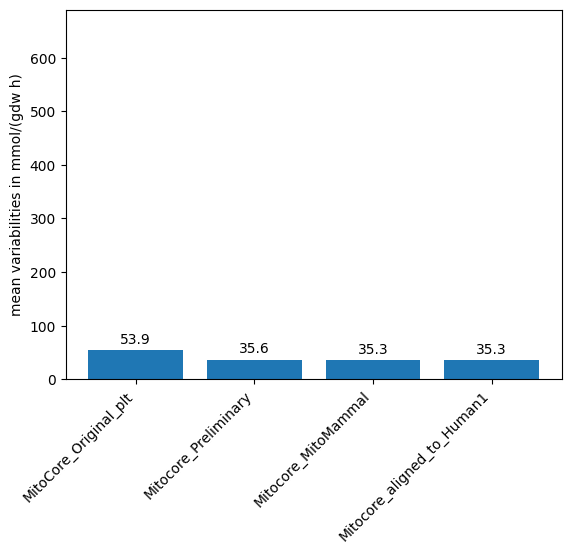

In [29]:
statistics_and_barplots(fva_ec_results_mapped_dict)

------------------MitoCore_Original_plt-----------------
# vars above 500: 46
# vars above 1000: 41
------------------Mitocore_Preliminary-----------------
# vars above 500: 30
# vars above 1000: 30
------------------Mitocore_MitoMammal-----------------
# vars above 500: 30
# vars above 1000: 30
------------------Mitocore_aligned_to_Human1-----------------
# vars above 500: 30
# vars above 1000: 30


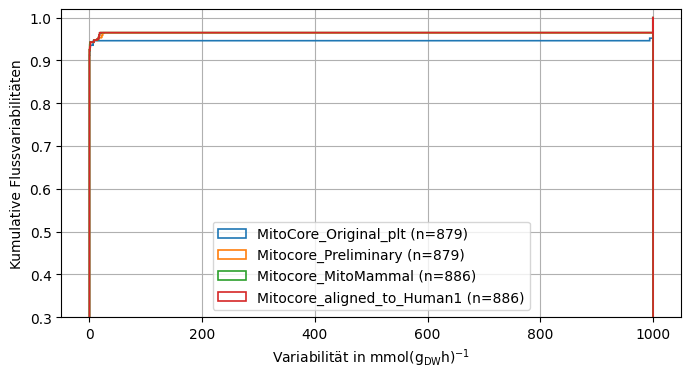

In [25]:
cumulative_flux_variability_graph(fva_ec_results_mapped_dict, '')

In [ ]:
# check which reactions are still fuled by loops
fva_ec_results_mapped_dict['curated'].loc[fva_ec_results_mapped_dict['curated']['range'] > 100]

,range
CKc_TG_forward,162.859103
CKc_TG_reverse,163.76535
CK_TG_forward,163.76535
CK_TG_reverse,162.859103
ATPtmB_MitoCore_TG_forward,164.576292
ATPtmB_MitoCore_TG_reverse,162.048161
MALtm_TG_forward,1000.0
MALtm_TG_reverse,1000.0
MALSO3tm_TG_forward,1000.0
MALSO3tm_TG_reverse,1000.0
